<a href="https://colab.research.google.com/github/EduardoKenzoHayashi/CN-Lobosco/blob/main/atividade2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 450 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 450 passos sem overflow.
dt=0.002, float64: 450 passos sem overflow.


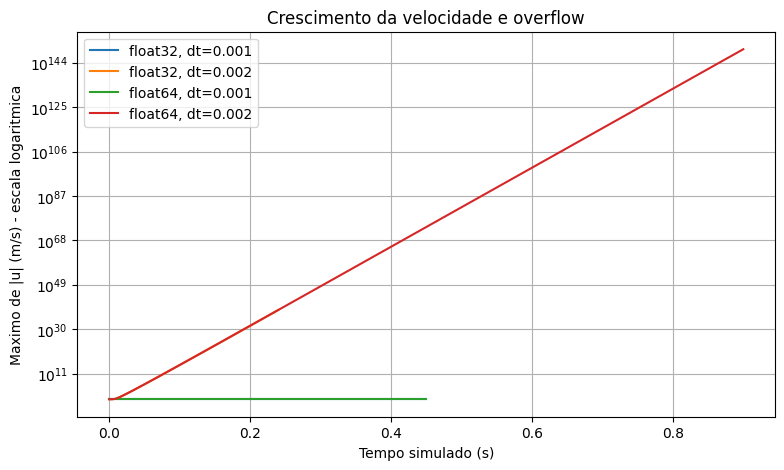

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simular(dt, tipo=np.float32, passos = 450, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = 0.4
    dy = H / (pontos - 1)
    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)
    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)
    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None
    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (u[1:-1] + r * (u[2:] - dois * u[1:-1] + u[:-2]))
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(f"dt={dt}, {tipo.__name__}: {passos} passos sem overflow.")

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}
#passo 1, 3 ,6 , 12
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

Parâmetro Valor
Distância entre placas, H 0,01 m
Viscosidade cinemática, ν 10−4 m2/s
Número de pontos, incluindo as paredes 21
Espaçamento, ∆y = H/(21 − 1) 0,0005 m
Velocidade da placa móvel, U 1 m/s
Velocidade da placa fixa 0 m/s
Para esses dados:

∆tmax =
(0,0005)2
2 × 10−4
= 0,00125 s.

Serão comparados:
• Caso A: ∆t = 0,001 s, com r = 0,4;
• Caso B: ∆t = 0,002 s, com r = 0,8.

Calcule ∆y, ∆tmax e r para os casos A e B. Classifique cada caso como estável ou instável
antes de executar o programa.

No caso A, como r < 1/2, há estabilidade

No caso B, como r>1/2, há instabilidade

In [ ]:
import pandas as pd

linhas = []
for nome, resultado in resultados.items():
    tipo, dt_str = nome.split(", dt=")
    linhas.append({
        "Tipo numérico": tipo,
        "Δt (s)": float(dt_str),
        "r": resultado["r"],
        "Estável (r ≤ 0.5)": "Sim" if resultado["r"] <= 0.5 else "Não",
        "Overflow": "Sim" if resultado["falha"] is not None else "Não",
        "Iteração da falha": resultado["falha"] if resultado["falha"] is not None else "-",
    })

tabela = pd.DataFrame(linhas)
print(tabela.to_string(index=False))

Tipo numérico  Δt (s)   r Estável (r ≤ 0.5) Overflow Iteração da falha
      float32   0.001 0.4               Sim      Não                 -
      float32   0.002 0.8               Não      Sim               121
      float64   0.001 0.4               Sim      Não                 -
      float64   0.002 0.8               Não      Não                 -


Analise o gráfico da maior velocidade em módulo ao longo do tempo. Explique por que o
crescimento observado no caso instável não representa o comportamento físico esperado.
Isso ocorre, pois a velocidade interna da placa acaba crescendo mais do que a velocidade de 1m/s. Logo, ela não representa o comportamento físico esperado que seria a velocidade ficar menor ou igual a 1m/s


4. Capacidade de representação.
Compare os resultados com float32 e float64. A mudança de tipo numérico elimina a
instabilidade? Justifique a diferença no número de passos até a falha.

Não. A única diferença é no número de passos, pois o float 64 apresenta mais vits disponíveis que o float 32, permitindo que o número de passos aumente significativamente.


Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 12 passos sem overflow.
dt=0.002, float32: 12 passos sem overflow.
dt=0.001, float64: 12 passos sem overflow.
dt=0.002, float64: 12 passos sem overflow.


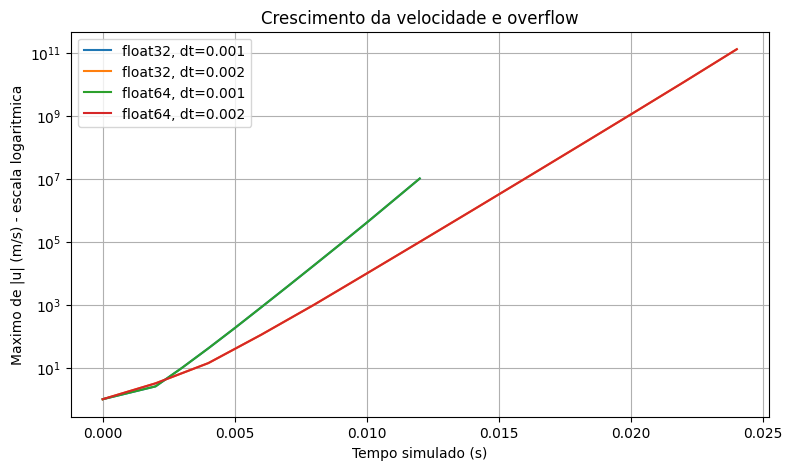

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simular(dt, tipo=np.float32, passos=12, pontos=41):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)
    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)
    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)
    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None
    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (u[1:-1] + r * (u[2:] - dois * u[1:-1] + u[:-2]))
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(f"dt={dt}, {tipo.__name__}: {passos} passos sem overflow.")

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

O aumento do número de pontos faz o delta y mudar, sendo igual a 0,00025 e o delta t max fica igual a 0,0003125. Essas mudanças fazem o r ficar igual a 1,6, o tornando bem mais estável.

Pata dekta t igual a 0,0002, temos r igual a 0,32, tornando o sistema em algo mais estyável, já que 0,32 > 0,5

dt=0.0002, float64: 6000 passos sem overflow.
Tempo total simulado: 1.2000 s
E_infinito = 4.546159e-06 m/s


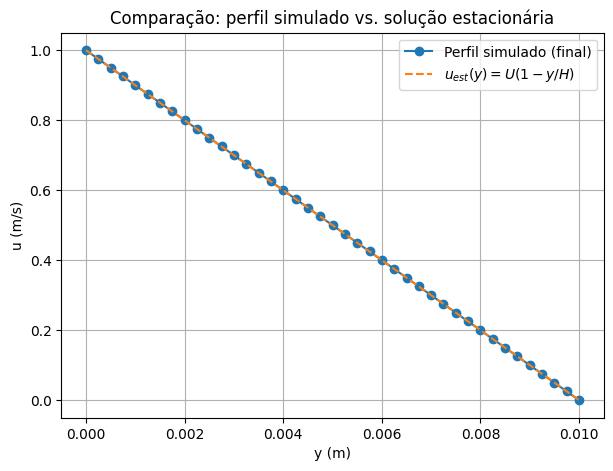

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Escolha um caso estável e execute com passos suficientes
# (veja discussão abaixo sobre quantos passos são necessários)
resultado = simular(dt=0.0002, tipo=np.float64, pontos=41, passos=6000)

U = 1.0
H = 0.01
y = resultado["y"]
u_final = resultado["u"]

u_est = U * (1 - y / H)

E_inf = np.max(np.abs(u_final - u_est))
print(f"Tempo total simulado: {resultado['tempos'][-1]:.4f} s")
print(f"E_infinito = {E_inf:.6e} m/s")

plt.figure(figsize=(7, 5))
plt.plot(y, u_final, 'o-', label="Perfil simulado (final)")
plt.plot(y, u_est, '--', label=r"$u_{est}(y) = U(1 - y/H)$")
plt.xlabel("y (m)")
plt.ylabel("u (m/s)")
plt.title("Comparação: perfil simulado vs. solução estacionária")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"tau (constante de tempo) ≈ {H**2/(np.pi**2 * 1e-4):.4f} s")
print(f"Tempo simulado = passos * dt = {resultado['tempos'][-1]:.4f} s")

tau (constante de tempo) ≈ 0.1013 s
Tempo simulado = passos * dt = 1.2000 s
